In [11]:
base_dir = '/home/mjehangir/telomere-sv-analysis/data/'

setwd(base_dir)

In [12]:
library(dplyr)
library(stringr)

In [13]:
# Read the tab-delimited file
df <- read.delim("nanoplot_summary.tsv", header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# Preview
head(df)

,SampleID,MeanReadLength,MeanReadQuality,MedianReadLength,MedianReadQuality,NumReads,ReadLengthN50,TotalBases,MaxReadLength
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,2436A_run3,2853.3,14.3,1127,16.2,28315810,7217,80792877398,744646
2,2436A_run5,2751.8,14.3,962,16.1,35965710,7947,98971403438,866944
3,3188,3149.5,13.6,1662,15.6,9447610,6031,29755703771,360440
4,3188_run6,2807.4,14.3,1139,16.2,26094461,6949,73256856075,467064
5,3988,3001.9,13.8,1155,15.6,29302691,7822,87963611558,450767
6,6265D,2219.8,13.5,986,15.2,19829040,4798,44015910757,345757


In [14]:

# Convert columns to numeric
df <- df %>%
  mutate(across(c(MeanReadLength, MeanReadQuality, MedianReadLength,
                  MedianReadQuality, NumReads, ReadLengthN50, TotalBases, MaxReadLength),
                as.numeric),
         BaseSampleID = str_replace(SampleID, "_run[0-9]+", ""))

# Weighted summarise
df_combined <- df %>%
  group_by(BaseSampleID) %>%
  summarise(
    NumReads = sum(NumReads, na.rm = TRUE),
    TotalBases = sum(TotalBases, na.rm = TRUE),
    MaxReadLength = max(MaxReadLength, na.rm = TRUE),
    MeanReadLength = sum(MeanReadLength * NumReads, na.rm = TRUE) / sum(NumReads, na.rm = TRUE),
    MedianReadLength = sum(MedianReadLength * NumReads, na.rm = TRUE) / sum(NumReads, na.rm = TRUE),
    MeanReadQuality = sum(MeanReadQuality * NumReads, na.rm = TRUE) / sum(NumReads, na.rm = TRUE),
    MedianReadQuality = sum(MedianReadQuality * NumReads, na.rm = TRUE) / sum(NumReads, na.rm = TRUE),
    ReadLengthN50 = sum(ReadLengthN50 * NumReads, na.rm = TRUE) / sum(NumReads, na.rm = TRUE),
    Coverage = TotalBases / 3100000000
  ) %>%
  ungroup()

print(df_combined)


# A tibble: 20 × 10
   BaseSampleID NumReads   TotalBases MaxReadLength MeanReadLength
   <chr>           <dbl>        <dbl>         <dbl>          <dbl>
 1 2436A        64281520 179764280836        866944          5605.
 2 3188         35542071 103012559846        467064          5957.
 3 3988         29302691  87963611558        450767          3002.
 4 6265D        52116063 119584928664        354542          4560.
 5 6266D        13998283  72319377548        561962          5166.
 6 6269C        21953038  92706961091        489083          8389.
 7 6277A        23488287  89683741887        425112          3818.
 8 6285B        27740446  79030518407        588681          2849.
 9 6298B        29468720  87036012899        588752          2954.
10 6314E        13987476  50307057674        275660          3597.
11 6324B        41710205  97638780448        382148          2341.
12 6365A        17247920  88183691810        541124          5113.
13 6414C        43215830  93629616398     

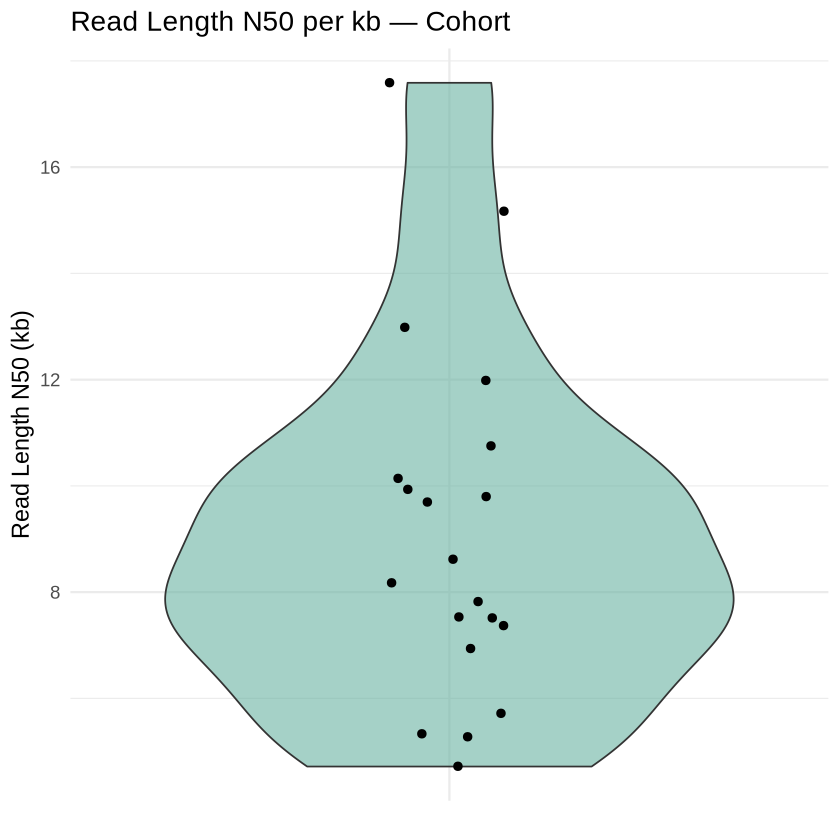

In [15]:
df_combined <- df_combined %>%
  mutate(ReadLengthN50_kb = ReadLengthN50 / 1000)
library(ggplot2)

p_cohort_n50 <- ggplot(df_combined, aes(x = "", y = ReadLengthN50_kb)) +
  geom_violin(fill = "#69b3a2", alpha = 0.6) +
  geom_jitter(width = 0.1, size = 2, color = "black") +
  labs(
    x = NULL,
    y = "Read Length N50 (kb)",
    title = "Read Length N50 per kb — Cohort"
  ) +
  theme_minimal(base_size = 14)
p_cohort_n50

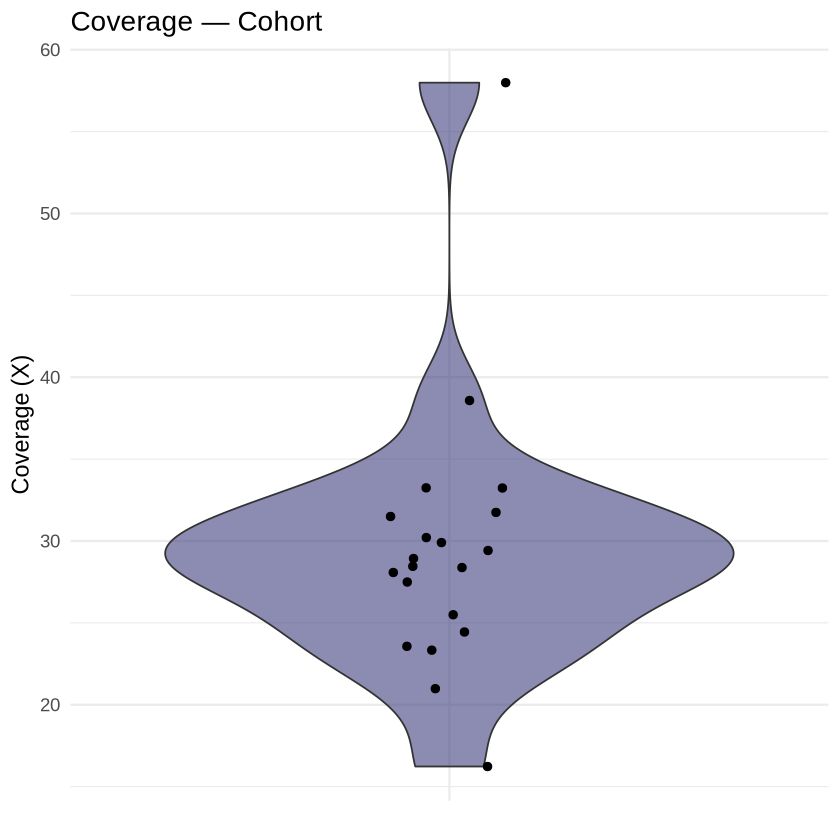

In [16]:
p_cohort_cov <- ggplot(df_combined, aes(x = "", y = Coverage)) +
  geom_violin(fill = "#404080", alpha = 0.6) +
  geom_jitter(width = 0.1, size = 2, color = "black") +
  labs(
    x = NULL,
    y = "Coverage (X)",
    title = "Coverage — Cohort"
  ) +
  theme_minimal(base_size = 14)
p_cohort_cov

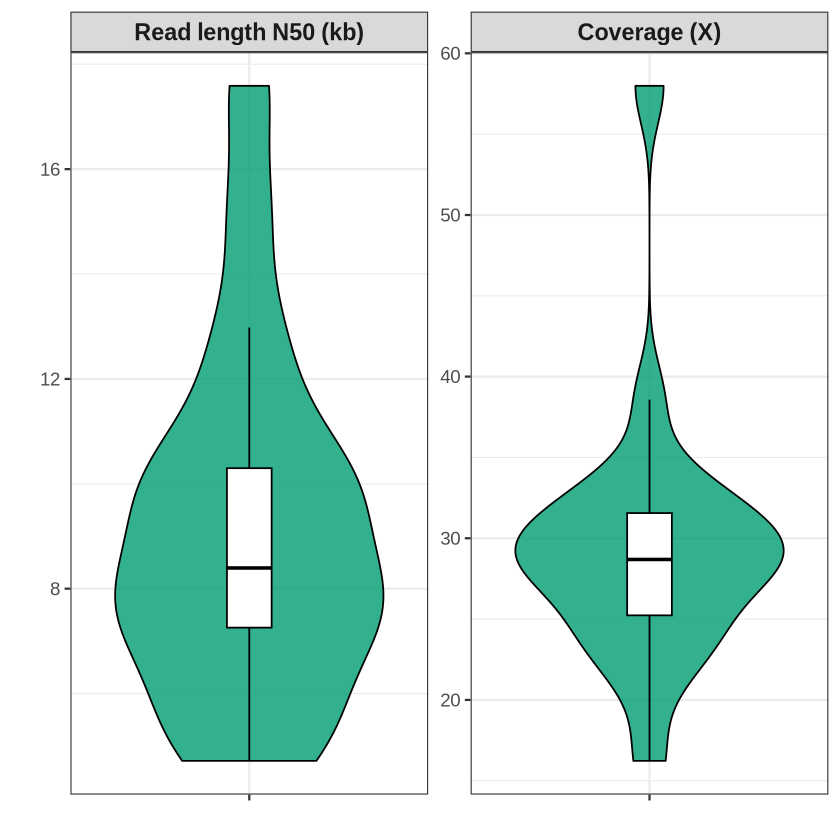

In [17]:


# Add N50 in kb if not already done
df_combined <- df_combined %>%
  mutate(ReadLengthN50_kb = ReadLengthN50 / 1000)

# Pivot longer for both metrics
df_long <- df_combined %>%
  select(BaseSampleID, ReadLengthN50_kb, Coverage) %>%
  pivot_longer(cols = c(ReadLengthN50_kb, Coverage),
               names_to = "Metric",
               values_to = "Value")

# Set nicer labels
df_long$Metric <- factor(df_long$Metric,
                         levels = c("ReadLengthN50_kb", "Coverage"),
                         labels = c("Read length N50 (kb)", "Coverage (X)"))

# Violin plots with free y-axis per metric
p <- ggplot(df_long, aes(x = "", y = Value, fill = Metric)) +
  geom_violin(trim = TRUE, alpha = 0.8, color = "black") +
  geom_boxplot(width = 0.15, outlier.shape = NA, fill = "white", color = "black") +
  scale_fill_manual(values = rep("#009e73", 2)) +  # same color
  facet_wrap(~Metric, scales = "free_y") +
  labs(x = "", y = "") +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "none",
    axis.text.x = element_blank(),
    axis.title.y = element_text(size = 14, face = "bold"),
    strip.text = element_text(face = "bold", size = 14)
  )

# Show plot
p

# Save figure
#ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig1/Cohort_N50_Coverage_freeY_violin.pdf", p, width = 8, height = 5, dpi = 600)
